# Partie C — Data Cleaning & Preprocessing
**Projet :** Estimation du prix des voitures d'occasion – Moteur.ma  
**Dataset :** `raw_moteur.csv` (8 184 lignes × 22 colonnes)  
**Objectif :** Nettoyer les données, gérer les valeurs manquantes et outliers, encoder, créer des features, normaliser, puis sauvegarder le dataset prêt pour la modélisation.

| Étape | Description |
|-------|-------------|
| 1 | Chargement & aperçu |
| 2 | Suppression des colonnes inutiles |
| 3 | Nettoyage des types (Kilométrage → numérique) |
| 4 | Valeurs manquantes |
| 5 | Outliers (IQR) |
| 6 | Feature Engineering |
| 7 | Encodage des variables catégorielles |
| 8 | Feature Selection |
| 9 | Normalisation / Standardisation |
| 10 | Sauvegarde du dataset propre |

---
## STEP 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

print('Imports OK')

Imports OK


---
## STEP 1 — Chargement & aperçu

In [4]:
df = pd.read_csv(r'C:\Users\HP\Downloads\raw_moteur.csv')
print(f'Shape : {df.shape}')
df.head()

Shape : (8184, 22)


,Lien_index,Marque,Modèle,Année,Kilométrage,Carburant,Transmission,Carrosserie,Couleur,Puissance fiscale,...,ville,État du véhicule,Airbags,Navigation GPS,Ordinateur de bord,Limiteur de vitesse,Climatisation,Intérieur cuir,Radar de recul,Cylindrée
0,0,Skoda,Superb,2019.0,"107,000 km",Diesel,Automatique,NaN,NaN,NaN,...,Casablanca,1,0,0,0,0,0,0,0,NaN
1,1,Nissan,Qashqai,2013.0,"178,000 km",Diesel,Manuelle,SUV et 4x4,Noir,7.0,...,NaN,0,0,0,0,0,0,0,0,NaN
2,2,Volkswagen,Golf 5,2007.0,"249,000 km",Diesel,Manuelle,Coupé,Bleu marine,8.0,...,Casablanca,0,1,1,0,0,1,0,0,NaN
3,3,Peugeot,2008,2014.0,"168,000 km",Diesel,Manuelle,NaN,NaN,6.0,...,Tanger,0,0,0,0,0,0,0,0,NaN
4,4,Citroën,C5,2019.0,"129,000 km",Diesel,Automatique,NaN,NaN,8.0,...,Casablanca,0,0,0,0,0,0,0,0,NaN


In [5]:
# Résumé des valeurs manquantes (héritage de la partie B)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Manquants': missing, '%': missing_pct}).sort_values('%', ascending=False)

,Manquants,%
Cylindrée,8182,99.98
Carrosserie,4864,59.43
Couleur,3593,43.90
Nombre de portes,2463,30.10
Puissance fiscale,1862,22.75
prix,1218,14.88
ville,691,8.44
Transmission,90,1.10
Carburant,45,0.55
Année,43,0.53


---
## STEP 2 — Suppression des colonnes inutiles

D'après la partie B :
- **`Cylindrée`** : 99.98 % de NaN → inutilisable, on supprime
- **`Lien_index`** : simple identifiant technique, aucune valeur prédictive
- **`Couleur`** : 43.9 % de NaN + faible corrélation avec le prix → on supprime
- **`Carrosserie`** : 59.4 % de NaN → trop de données manquantes
- **`Nombre de portes`** : 30 % de NaN, quasi-constante (95 % = 5 portes) → on supprime

In [6]:
cols_to_drop = ['Cylindrée', 'Lien_index', 'Couleur', 'Carrosserie', 'Nombre de portes']
df.drop(columns=cols_to_drop, inplace=True)
print(f'Colonnes supprimées : {cols_to_drop}')
print(f'Shape après suppression : {df.shape}')

Colonnes supprimées : ['Cylindrée', 'Lien_index', 'Couleur', 'Carrosserie', 'Nombre de portes']
Shape après suppression : (8184, 17)


---
## STEP 3 — Nettoyage des types

**`Kilométrage`** est une chaîne de caractères (`'107,000 km'`) → on extrait la valeur numérique.

In [7]:
# Exemple avant nettoyage
print('Avant :', df['Kilométrage'].head(3).tolist())

# Supprime 'km', virgules, espaces → conversion en float
df['Kilométrage'] = (
    df['Kilométrage']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

print('Après :', df['Kilométrage'].head(3).tolist())
print(f'Type : {df["Kilométrage"].dtype}')

Avant : ['107,000 km', '178,000 km', '249,000 km']
Après : [107000.0, 178000.0, 249000.0]
Type : float64


---
## STEP 4 — Valeurs manquantes

Stratégie par colonne :

| Colonne | Stratégie | Raison |
|---------|-----------|--------|
| `prix` | **Suppression des lignes** | C'est la cible — on ne peut pas l'imputer |
| `Année` | **Médiane** | Numérique, distribution légèrement skewed |
| `Kilométrage` | **Médiane** | Numérique, outliers possibles |
| `Puissance fiscale` | **Médiane** | Numérique, quelques outliers extrêmes |
| `Carburant` | **Mode** | Catégorielle, Diesel très dominant |
| `Transmission` | **Mode** | Catégorielle, Manuelle très dominant |
| `ville` | **'Inconnu'** | Catégorielle, trop de valeurs uniques pour imputer |
| `Marque`, `Modèle` | **Suppression des lignes** | Peu de NaN (0.39 %), colonnes essentielles |

In [8]:
print(f'Shape avant traitement NaN : {df.shape}')

# 1. Supprimer les lignes sans prix (cible manquante)
df.dropna(subset=['prix'], inplace=True)
print(f'Après suppression prix NaN   : {df.shape}')

# 2. Supprimer les lignes sans Marque ou Modèle (peu nombreuses, essentielles)
df.dropna(subset=['Marque', 'Modèle'], inplace=True)
print(f'Après suppression Marque/Modèle NaN : {df.shape}')

# 3. Imputation par médiane pour les colonnes numériques
for col in ['Année', 'Kilométrage', 'Puissance fiscale']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'  {col} → imputé avec médiane = {median_val}')

# 4. Imputation par mode pour les colonnes catégorielles
for col in ['Carburant', 'Transmission']:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f'  {col} → imputé avec mode = {mode_val}')

# 5. Ville : remplacer les NaN par 'Inconnu'
df['ville'].fillna('Inconnu', inplace=True)

# Vérification finale
remaining_nan = df.isnull().sum().sum()
print(f'\nValeurs manquantes restantes : {remaining_nan}')
print(f'Shape final : {df.shape}')

Shape avant traitement NaN : (8184, 17)
Après suppression prix NaN   : (6966, 17)
Après suppression Marque/Modèle NaN : (6966, 17)
  Année → imputé avec médiane = 2019.0
  Kilométrage → imputé avec médiane = 101999.5
  Puissance fiscale → imputé avec médiane = 8.0
  Carburant → imputé avec mode = Diesel
  Transmission → imputé avec mode = Automatique

Valeurs manquantes restantes : 0
Shape final : (6966, 17)


---
## STEP 5 — Outliers

On applique la méthode **IQR (Interquartile Range)** sur les colonnes numériques sensibles : `prix`, `Kilométrage`, `Puissance fiscale`.  
On retire les valeurs en dehors de `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.

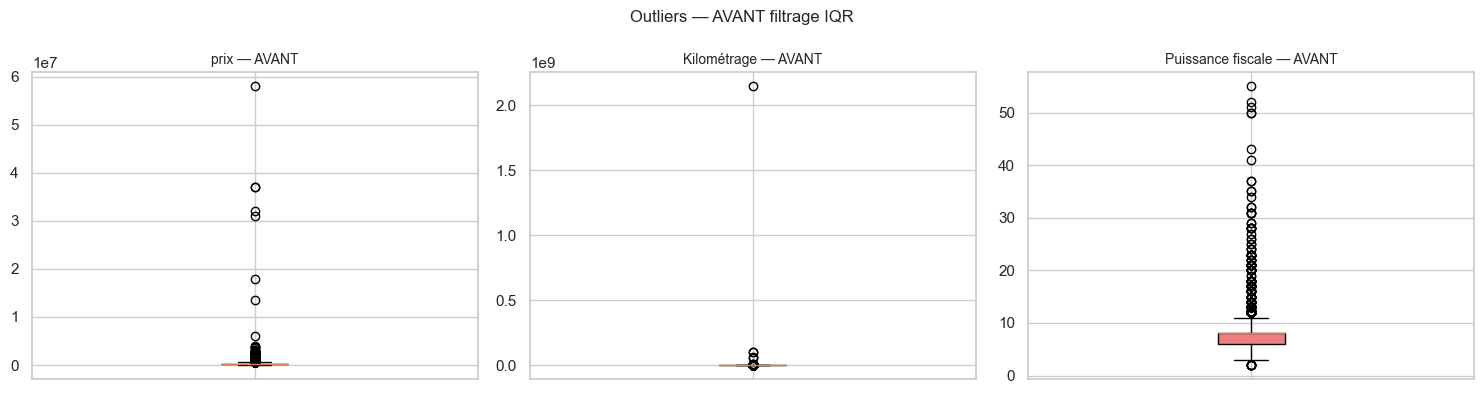

In [9]:
# Visualisation AVANT filtrage
cols_outlier = ['prix', 'Kilométrage', 'Puissance fiscale']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cols_outlier):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightcoral'))
    axes[i].set_title(f'{col} — AVANT', fontsize=10)
    axes[i].tick_params(axis='x', labelbottom=False)
plt.suptitle('Outliers — AVANT filtrage IQR', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = len(df)
    print(f'  {col}: [{lower:.0f} – {upper:.0f}] → {before - after} lignes supprimées ({after} restantes)')
    return df

print(f'Shape avant outliers : {df.shape}')
for col in cols_outlier:
    df = remove_outliers_iqr(df, col)

print(f'\nShape après outliers : {df.shape}')

Shape avant outliers : (6966, 17)
  prix: [-105000 – 535000] → 429 lignes supprimées (6537 restantes)
  Kilométrage: [-104000 – 328000] → 184 lignes supprimées (6353 restantes)
  Puissance fiscale: [3 – 11] → 382 lignes supprimées (5971 restantes)

Shape après outliers : (5971, 17)


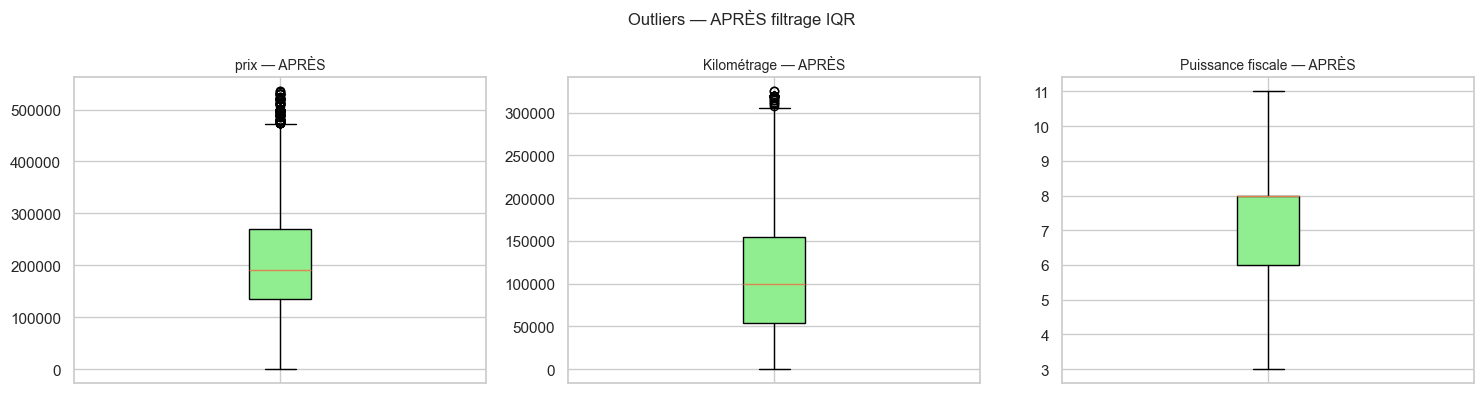

In [11]:
# Visualisation APRÈS filtrage
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cols_outlier):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'))
    axes[i].set_title(f'{col} — APRÈS', fontsize=10)
    axes[i].tick_params(axis='x', labelbottom=False)
plt.suptitle('Outliers — APRÈS filtrage IQR', fontsize=12)
plt.tight_layout()
plt.show()

---
## STEP 6 — Feature Engineering

On crée de nouvelles variables pertinentes à partir des données existantes.

In [12]:
CURRENT_YEAR = 2026

# 1. Âge de la voiture
df['age_voiture'] = CURRENT_YEAR - df['Année']

# 2. Kilométrage par an (proxy d'usure)
# On évite la division par zéro pour les voitures de l'année
df['km_par_an'] = df.apply(
    lambda row: row['Kilométrage'] / row['age_voiture'] if row['age_voiture'] > 0 else row['Kilométrage'],
    axis=1
)

# 3. Score d'options (nombre d'équipements de confort présents)
option_cols = ['Airbags', 'Navigation GPS', 'Ordinateur de bord',
               'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul']
df['score_options'] = df[option_cols].sum(axis=1)

# 4. Voiture récente (binaire : année >= 2018)
df['voiture_recente'] = (df['Année'] >= 2018).astype(int)

print(' Features créées :')
print('  - age_voiture')
print('  - km_par_an')
print('  - score_options')
print('  - voiture_recente')
df[['Année', 'age_voiture', 'Kilométrage', 'km_par_an', 'score_options', 'voiture_recente']].head()

 Features créées :
  - age_voiture
  - km_par_an
  - score_options
  - voiture_recente


,Année,age_voiture,Kilométrage,km_par_an,score_options,voiture_recente
0,2019.0,7.0,107000.0,15285.714286,0,1
1,2013.0,13.0,178000.0,13692.307692,0,0
2,2007.0,19.0,249000.0,13105.263158,3,0
3,2014.0,12.0,168000.0,14000.000000,0,0
4,2019.0,7.0,129000.0,18428.571429,0,1


---
## STEP 7 — Encodage des variables catégorielles

| Variable | Cardinalité | Méthode |
|----------|-------------|---------|
| `Carburant` | Faible (~5 valeurs) | **LabelEncoder** |
| `Transmission` | Faible (~3 valeurs) | **LabelEncoder** |
| `État du véhicule` | Binaire (0/1) | Déjà encodé |
| `Marque` | Moyenne (~40 valeurs) | **Target Encoding** (moyenne prix par marque) |
| `ville` | Moyenne (~50 valeurs) | **Target Encoding** (moyenne prix par ville) |
| `Modèle` | Haute (>200 valeurs) | **Target Encoding** (moyenne prix par modèle) |

In [15]:
# --- LabelEncoder pour Carburant et Transmission ---
le_carburant    = LabelEncoder()
le_transmission = LabelEncoder()

df['Carburant_enc']    = le_carburant.fit_transform(df['Carburant'].astype(str))
df['Transmission_enc'] = le_transmission.fit_transform(df['Transmission'].astype(str))

print('Carburant     :', dict(zip(le_carburant.classes_, le_carburant.transform(le_carburant.classes_))))
print('Transmission  :', dict(zip(le_transmission.classes_, le_transmission.transform(le_transmission.classes_))))

# Sauvegarder les encodeurs pour l'inférence future
joblib.dump(le_carburant,    '../Downloads/le_carburant.pkl')
joblib.dump(le_transmission, '../Downloads/le_transmission.pkl')
print('\n Encodeurs sauvegardés.')

Carburant     : {'Diesel': np.int64(0), 'Essence': np.int64(1), 'Hybride': np.int64(2), 'Électrique': np.int64(3)}
Transmission  : {'Automatique': np.int64(0), 'Manuelle': np.int64(1), 'Semi-automatique': np.int64(2)}

 Encodeurs sauvegardés.


In [16]:
# --- Target Encoding pour Marque, Modèle et ville ---
# On calcule la moyenne du prix cible par catégorie

for col in ['Marque', 'Modèle', 'ville']:
    target_mean = df.groupby(col)['prix'].mean()
    df[f'{col}_enc'] = df[col].map(target_mean)
    # Imputer les éventuelles catégories sans correspondance (ex: 'Inconnu')
    df[f'{col}_enc'].fillna(df['prix'].mean(), inplace=True)
    print(f'  {col} → target encoded ({df[col].nunique()} catégories)')

print('\n Encodage terminé')

  Marque → target encoded (66 catégories)
  Modèle → target encoded (413 catégories)
  ville → target encoded (21 catégories)

 Encodage terminé


---
## STEP 8 — Feature Selection

On supprime les colonnes originales qui ont été encodées ou remplacées, et on affiche la matrice de corrélation finale.

In [17]:
# Supprimer les colonnes textuelles originales (remplacées par les encodées)
cols_raw_text = ['Marque', 'Modèle', 'Carburant', 'Transmission', 'ville', 'Année']
df.drop(columns=cols_raw_text, inplace=True)

print(f'Colonnes finales ({len(df.columns)}) :')
print(df.columns.tolist())

Colonnes finales (20) :
['Kilométrage', 'Puissance fiscale', 'prix', 'État du véhicule', 'Airbags', 'Navigation GPS', 'Ordinateur de bord', 'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul', 'age_voiture', 'km_par_an', 'score_options', 'voiture_recente', 'Carburant_enc', 'Transmission_enc', 'Marque_enc', 'Modèle_enc', 'ville_enc']


Corrélation avec prix (triée) :
Modèle_enc             0.759
Transmission_enc      -0.595
Marque_enc             0.538
voiture_recente        0.475
Puissance fiscale      0.296
Kilométrage           -0.222
age_voiture           -0.207
ville_enc              0.197
Intérieur cuir         0.183
km_par_an              0.180
Navigation GPS         0.131
Ordinateur de bord     0.122
score_options          0.107
Radar de recul         0.101
Limiteur de vitesse    0.096
État du véhicule       0.073
Climatisation          0.039
Airbags               -0.017
Carburant_enc         -0.009


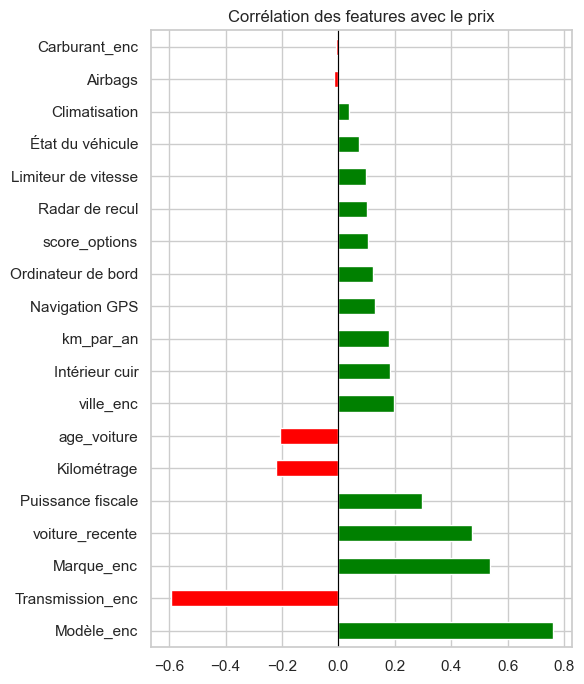

In [18]:
# Matrice de corrélation avec la cible 'prix'
corr = df.corr(numeric_only=True)
corr_with_prix = corr['prix'].drop('prix').sort_values(key=abs, ascending=False)

print('Corrélation avec prix (triée) :')
print(corr_with_prix.round(3).to_string())

# Visualisation
plt.figure(figsize=(6, 7))
corr_with_prix.plot(kind='barh', color=['green' if x > 0 else 'red' for x in corr_with_prix])
plt.title('Corrélation des features avec le prix', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [19]:
# Supprimer les features avec corrélation très faible (< 0.03 en valeur absolue)
low_corr_threshold = 0.03
low_corr_cols = corr_with_prix[corr_with_prix.abs() < low_corr_threshold].index.tolist()

if low_corr_cols:
    print(f'Colonnes faiblement corrélées supprimées : {low_corr_cols}')
    df.drop(columns=low_corr_cols, inplace=True)
else:
    print('Toutes les features ont une corrélation suffisante avec le prix.')

print(f'Shape final avant normalisation : {df.shape}')

Colonnes faiblement corrélées supprimées : ['Airbags', 'Carburant_enc']
Shape final avant normalisation : (5971, 18)


---
## STEP 9 — Normalisation / Standardisation

On applique **StandardScaler** (moyenne=0, écart-type=1) sur toutes les features numériques **sauf la cible `prix`**.  
Le scaler est sauvegardé pour être réutilisé lors de l'inférence (partie D/E).

In [22]:
# Identifier les colonnes à scaler (toutes numériques sauf 'prix')
feature_cols = [c for c in df.columns if c != 'prix']

print(f'Features à normaliser ({len(feature_cols)}) :')
print(feature_cols)

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# Sauvegarder le scaler
joblib.dump(scaler, '../Downloads/scaler.pkl')
print('\n Scaler sauvegardé dans ../Downloads/scaler.pkl')

# Vérification rapide
print(f'\nMoyenne des features (doit être ≈ 0) :')
print(df[feature_cols].mean().round(3).to_string())

Features à normaliser (17) :
['Kilométrage', 'Puissance fiscale', 'État du véhicule', 'Navigation GPS', 'Ordinateur de bord', 'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul', 'age_voiture', 'km_par_an', 'score_options', 'voiture_recente', 'Transmission_enc', 'Marque_enc', 'Modèle_enc', 'ville_enc']

 Scaler sauvegardé dans ../Downloads/scaler.pkl

Moyenne des features (doit être ≈ 0) :
Kilométrage            0.0
Puissance fiscale      0.0
État du véhicule      -0.0
Navigation GPS        -0.0
Ordinateur de bord    -0.0
Limiteur de vitesse   -0.0
Climatisation          0.0
Intérieur cuir         0.0
Radar de recul        -0.0
age_voiture            0.0
km_par_an              0.0
score_options         -0.0
voiture_recente        0.0
Transmission_enc       0.0
Marque_enc             0.0
Modèle_enc            -0.0
ville_enc              0.0


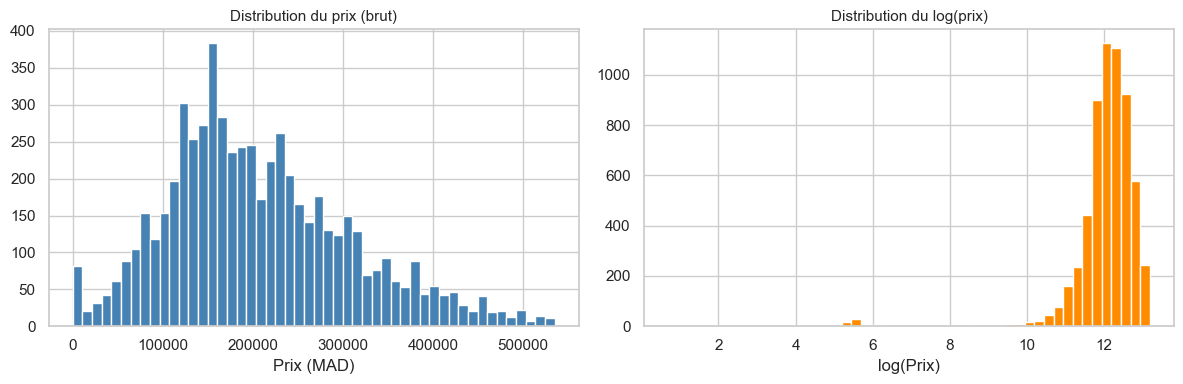

 Colonne log_prix ajoutée (utile pour les modèles linéaires).


In [23]:
# Distribution de la cible PRIX (on applique log1p pour réduire le skew)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['prix'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du prix (brut)', fontsize=11)
axes[0].set_xlabel('Prix (MAD)')

axes[1].hist(np.log1p(df['prix']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution du log(prix)', fontsize=11)
axes[1].set_xlabel('log(Prix)')

plt.tight_layout()
plt.show()

# On crée une colonne log_prix pour les modèles sensibles au skew
df['log_prix'] = np.log1p(df['prix'])
print(' Colonne log_prix ajoutée (utile pour les modèles linéaires).')

---
## STEP 10 — Aperçu du dataset final

In [24]:
print(f' Dataset propre : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f' Valeurs manquantes restantes : {df.isnull().sum().sum()}')
print()
df.describe().round(3)

 Dataset propre : 5971 lignes × 19 colonnes
 Valeurs manquantes restantes : 0



,Kilométrage,Puissance fiscale,prix,État du véhicule,Navigation GPS,Ordinateur de bord,Limiteur de vitesse,Climatisation,Intérieur cuir,Radar de recul,age_voiture,km_par_an,score_options,voiture_recente,Transmission_enc,Marque_enc,Modèle_enc,ville_enc,log_prix
count,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000,5971.000
mean,0.000,0.000,207102.092,-0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,12.033
std,1.000,1.000,103024.142,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.970
min,-1.504,-3.532,1.000,-0.507,-0.797,-0.872,-0.921,-1.020,-0.665,-0.908,-0.137,-1.543,-1.039,-1.401,-0.827,-3.738,-2.649,-4.345,0.693
25%,-0.758,-1.146,135000.000,-0.507,-0.797,-0.872,-0.921,-1.020,-0.665,-0.908,-0.116,-0.537,-1.039,-1.401,-0.827,-0.737,-0.803,-0.680,11.813
50%,-0.129,0.446,190000.000,-0.507,-0.797,-0.872,-0.921,0.981,-0.665,-0.908,-0.100,-0.063,-0.035,0.714,-0.827,0.056,-0.138,0.706,12.155
75%,0.627,0.446,270000.000,-0.507,1.255,1.147,1.086,0.981,1.505,1.102,-0.085,0.427,0.970,0.714,1.207,0.512,0.802,0.706,12.506
max,2.965,2.832,535000.000,1.973,1.255,1.147,1.086,0.981,1.505,1.102,10.367,21.099,1.305,0.714,3.242,3.406,3.938,0.797,13.190


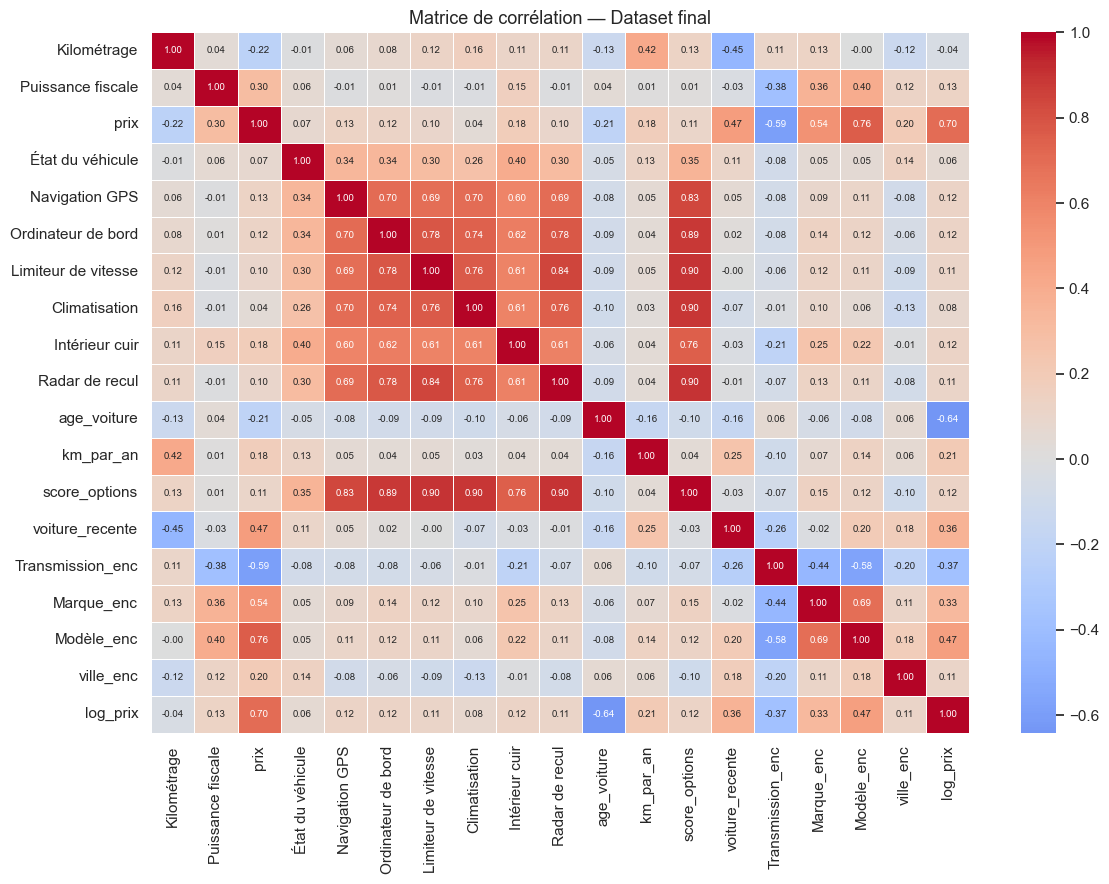

In [25]:
# Heatmap de corrélation finale
plt.figure(figsize=(12, 9))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, annot_kws={'size': 7}
)
plt.title('Matrice de corrélation — Dataset final', fontsize=13)
plt.tight_layout()
plt.show()

---
## STEP 11 — Sauvegarde du dataset propre

In [27]:
OUTPUT_PATH = '../Downloads/moteur_clean.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f'   Dataset sauvegardé : {OUTPUT_PATH}')
print(f'   Lignes  : {df.shape[0]}')
print(f'   Colonnes: {df.shape[1]}')
print(f'   Colonnes: {df.columns.tolist()}')

   Dataset sauvegardé : ../Downloads/moteur_clean.csv
   Lignes  : 5971
   Colonnes: 19
   Colonnes: ['Kilométrage', 'Puissance fiscale', 'prix', 'État du véhicule', 'Navigation GPS', 'Ordinateur de bord', 'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul', 'age_voiture', 'km_par_an', 'score_options', 'voiture_recente', 'Transmission_enc', 'Marque_enc', 'Modèle_enc', 'ville_enc', 'log_prix']
